# NNDL Week 1

**Name: Shashank Goel**
**Roll no: J011**
**SAP ID: 70092300008**
**Batch: B.Tech Data Science**

# Practical 1 — Can one neuron learn?

In the theory session we trained a network of 17 neurons on cats. Today we go smaller: **one neuron, built from nothing but numpy**, every line yours.

And we'll build the exact machine from the lecture's story: **a bank's loan officer**. Two facts about each applicant — salary and existing debt — one approve/reject decision, and a scorecard the neuron must learn on its own.

This is not an implementation drill. It's an experiment, and the question is in the title. By the end you'll also break the neuron three different ways — on purpose — and then send it into a rematch against the cat dataset that ends... surprisingly.

*(Everything here is sections 4–10 of the week-1 notes, made runnable. Keep the notes open beside you.)*

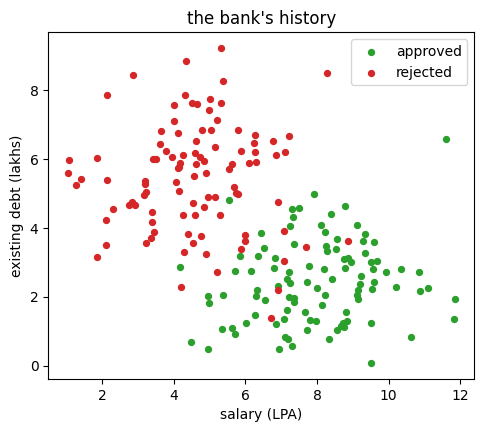

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# The bank's history: 200 past loan applications, 2 facts each.
#   x1 = salary (lakhs per annum)     x2 = existing debt (lakhs)
# Approved applicants trend high-salary, low-debt. But banks are made of
# people — the clouds overlap.
rng = np.random.default_rng(42)
m = 200
approved = rng.normal([8.0, 2.5], [1.8, 1.4], (m // 2, 2))
rejected = rng.normal([4.5, 5.5], [1.5, 1.6], (m // 2, 2))
applicants = np.vstack([approved, rejected])
applicants[:, 1] = np.maximum(applicants[:, 1], 0)   # debt can't be negative

X = applicants.T                                  # shape (2, m) — each COLUMN is one applicant
y = np.array([1] * (m // 2) + [0] * (m // 2)).reshape(1, -1)   # 1 = approved

def show_data(ax=None):
    ax = ax or plt.gca()
    ax.scatter(*X[:, y[0] == 1], c="tab:green", s=18, label="approved")
    ax.scatter(*X[:, y[0] == 0], c="tab:red", s=18, label="rejected")
    ax.set(xlabel="salary (LPA)", ylabel="existing debt (lakhs)")
    ax.legend()

plt.figure(figsize=(5.5, 4.5)); show_data(); plt.title("the bank's history"); plt.show()

## 1. Build the neuron: score, then squash

The whole loan officer fits in two lines of math:

$$z = w_1 x_1 + w_2 x_2 + b \qquad\qquad a = \sigma(z) = \frac{1}{1+e^{-z}}$$

$w_1, w_2$ are the scorecard points for salary and debt, $b$ is the bank's standing skepticism, $a$ is the claimed probability of *approval*.

We start all knobs at **zero**: an officer with no opinions. Watch what that looks like.

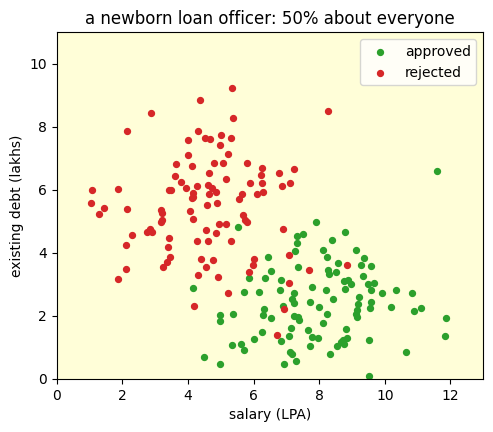

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def neuron(w, b, X):
    """The forward pass: score every column of X, squash to a probability."""
    return sigmoid(w[0] * X[0] + w[1] * X[1] + b)

def show_mind(w, b, ax=None, title=""):
    """Paint the neuron's belief over the whole plane + its decision boundary."""
    ax = ax or plt.gca()
    g1, g2 = np.meshgrid(np.linspace(0, 13, 200), np.linspace(0, 11, 200))
    beliefs = neuron(w, b, np.vstack([g1.ravel(), g2.ravel()])).reshape(g1.shape)
    ax.contourf(g1, g2, beliefs, levels=20, cmap="RdYlGn", alpha=0.6, vmin=0, vmax=1)
    ax.contour(g1, g2, beliefs, levels=[0.5], colors="k", linewidths=2)  # the boundary: z = 0
    show_data(ax)
    ax.set_title(title)

w, b = np.zeros(2), 0.0
plt.figure(figsize=(5.5, 4.5))
show_mind(w, b, title="a newborn loan officer: 50% about everyone")
plt.show()

## 2. Teach it: embarrassment, blame, step

The training loop, exactly as in the notes — the honest version, with its loop over every example:

1. **score & squash** each applicant → $a$
2. **embarrassment**: $\mathcal{L} = -(y\log a + (1-y)\log(1-a))$, averaged into the cost $J$
3. **the collapse**: $\texttt{d}z = a - y$ — the error *is* the correction
4. **blame each knob**: $\texttt{d}w_1 = x_1\,\texttt{d}z$, $\texttt{d}w_2 = x_2\,\texttt{d}z$, $\texttt{d}b = \texttt{d}z$, averaged over the class
5. **step downhill**: $w := w - \alpha\,\texttt{d}w$

In [3]:
def train(w, b, X, y, lr=0.1, epochs=500, snap_every=None):
    """Full-batch gradient descent. Returns trained (w, b), the loss history,
    and snapshots of the knobs along the way (for the film strip below)."""
    w, b = w.copy(), float(b)
    m = X.shape[1]
    losses, snaps = [], []
    for epoch in range(epochs):
        dw, db, J = np.zeros(2), 0.0, 0.0
        for i in range(m):                       # ← remember this loop. Its days are numbered.
            a = neuron(w, b, X[:, i:i+1])[0]     # score & squash one applicant
            J += -(y[0, i] * np.log(a + 1e-12) + (1 - y[0, i]) * np.log(1 - a + 1e-12))
            dz = a - y[0, i]                     # the collapse
            dw += X[:, i] * dz                   # blame, proportional to input volume
            db += dz
        w -= lr * dw / m                         # one averaged step downhill
        b -= lr * db / m
        losses.append(J / m)
        if snap_every and (epoch % snap_every == 0 or epoch == epochs - 1):
            snaps.append((epoch, w.copy(), b))
    return w, b, losses, snaps

w, b, losses, snaps = train(np.zeros(2), 0.0, X, y, lr=0.1, epochs=500, snap_every=100)
acc = np.mean((neuron(w, b, X) > 0.5) == y[0])
print(f"final loss {losses[-1]:.3f}   accuracy {acc:.0%}")

final loss 0.178   accuracy 93%


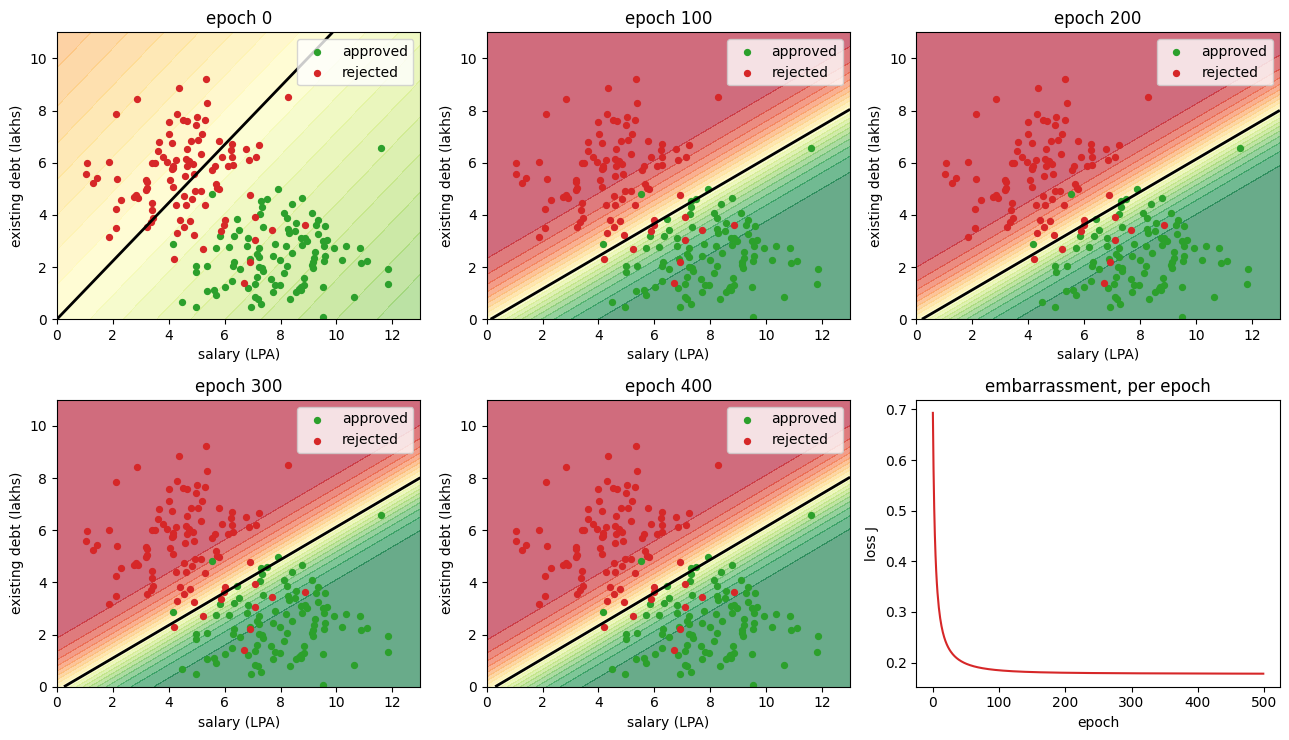

In [4]:
# the film strip: watch the boundary swing into place as embarrassment falls
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, (ep, ws, bs) in zip(axes.flat[:5], snaps):
    show_mind(ws, bs, ax, title=f"epoch {ep}")
axes.flat[5].plot(losses, color="tab:red")
axes.flat[5].set(title="embarrassment, per epoch", xlabel="epoch", ylabel="loss J")
plt.tight_layout(); plt.show()

## 3. Read the scorecard

This is the luxury of one neuron: you can *read its mind*. And what it learned, with nobody telling it to, is a genuine bank scorecard — salary **earns** points, debt **costs** points. This interpretability is exactly why banks still run logistic regression in production today: a regulator can read the weights.

In [5]:
print("THE LEARNED SCORECARD")
print(f"  salary        : {w[0]:+.2f} points per lakh of salary")
print(f"  existing debt : {w[1]:+.2f} points per lakh of debt")
print(f"  standing bias : {b:+.2f}  (the bank's skepticism before reading any application)")
print()
applicant = np.array([[9.0], [6.5]])   # earns well — but drowning in EMIs
p = neuron(w, b, applicant)[0]
print(f"9 LPA salary, 6.5 lakhs of debt → {p:.0%} chance of approval")

THE LEARNED SCORECARD
  salary        : +0.95 points per lakh of salary
  existing debt : -1.50 points per lakh of debt
  standing bias : -0.34  (the bank's skepticism before reading any application)

9 LPA salary, 6.5 lakhs of debt → 19% chance of approval


---
## 4. 💥 Break it #1: crank the learning rate 100×

The notes said stride length is delicate: too big and you leap *across* the valley, landing higher than you started. Let's stop taking that on faith. Same neuron, same data, `lr=10` instead of `0.1`.

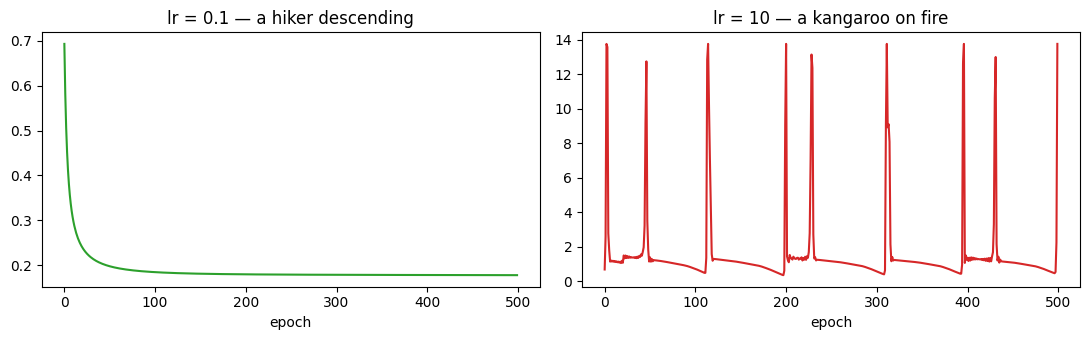

In [6]:
_, _, losses_wild, _ = train(np.zeros(2), 0.0, X, y, lr=10.0, epochs=500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5), sharey=False)
ax1.plot(losses, color="tab:green"); ax1.set(title="lr = 0.1 — a hiker descending", xlabel="epoch")
ax2.plot(losses_wild, color="tab:red"); ax2.set(title="lr = 10 — a kangaroo on fire", xlabel="epoch")
plt.tight_layout(); plt.show()

> **Tweak this:** somewhere between 0.1 and 10 the hiker becomes the kangaroo. Binary-search the breaking point. Is the transition gradual or a cliff? Also try `lr=0.001` — how many epochs does the baby-stepper need to match `lr=0.1`?

## 💥 Break it #2: does the starting point matter?

We started every knob at zero, which feels lazy. Surely a random start changes what the neuron learns?

In [7]:
for seed in [0, 1, 99]:
    w0 = np.random.default_rng(seed).normal(0, 5, 2)   # wild random starts
    wf, bf, lf, _ = train(w0, 0.0, X, y, lr=0.1, epochs=500)
    print(f"start {np.round(w0, 2)} → final w {np.round(wf, 2)}, b {bf:+.2f}, loss {lf[-1]:.3f}")

start [ 0.63 -0.66] → final w [ 0.96 -1.5 ], b -0.34, loss 0.178
start [1.73 4.11] → final w [ 1.   -1.45], b -0.82, loss 0.176
start [ 0.41 -2.32] → final w [ 0.97 -1.56], b -0.18, loss 0.179


Every start converges to the **same** scorecard. That's the convex bowl from the notes: one valley, all roads lead to it. Zero-init is perfectly fine for one neuron.

> **Remember this result.** Write it down somewhere annoying. In the shallow-networks week we'll initialize a *two-layer* network with zeros, and something genuinely weird will happen. The question to hold on to: *what breaks when the zeros have colleagues?*

## 💥 Break it #3: poison the labels

Real datasets are dirty — somewhere in the bank's archive, a bored clerk entered 10% of the old decisions wrong. Flip 10% of the labels and retrain.

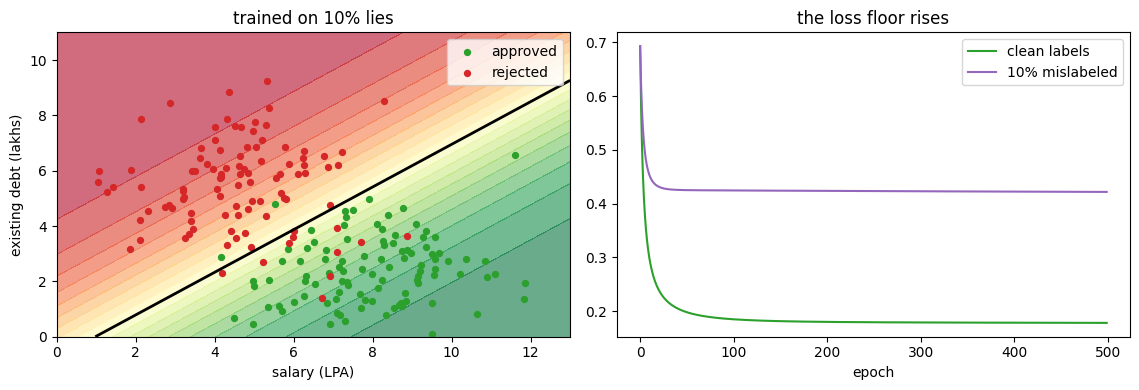

boundary weights, clean: [ 0.95 -1.5 ]   dirty: [ 0.45 -0.59]


In [8]:
y_dirty = y.copy()
flip = rng.choice(m, m // 10, replace=False)
y_dirty[0, flip] = 1 - y_dirty[0, flip]

w_d, b_d, losses_d, _ = train(np.zeros(2), 0.0, X, y_dirty, lr=0.1, epochs=500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4))
show_mind(w_d, b_d, ax1, title="trained on 10% lies")
ax2.plot(losses, label="clean labels", color="tab:green")
ax2.plot(losses_d, label="10% mislabeled", color="tab:purple")
ax2.set(title="the loss floor rises", xlabel="epoch"); ax2.legend()
plt.tight_layout(); plt.show()
print(f"boundary weights, clean: {np.round(w, 2)}   dirty: {np.round(w_d, 2)}")

Two lessons hiding here: the loss can never reach zero when the labels lie (a **loss floor** — a high final loss doesn't always mean a bad model; sometimes it means dirty data), yet the *boundary barely moved*. The average-of-all-blame update quietly outvotes a minority of liars.

> **Break it more:** how much poison until the boundary actually degrades? Try 25%, then 40%, then 50%. What should 50% give you, logically?

---
## 5. 🔍 Trust, but verify: is `dz = a − y` actually true?

The notes claim all that calculus collapses to *prediction minus truth*. You shouldn't believe it because I said so — and you don't have to, because a derivative has an **honest physical meaning** you can measure: nudge the knob, watch the cost.

$$\frac{\partial J}{\partial w_1} \approx \frac{J(w_1 + h) - J(w_1 - h)}{2h}\quad\text{for tiny } h$$

No calculus on the right side — just two cost evaluations. If our formula disagrees with this, our formula is wrong. (This exact check caught a real bug in `tinynet.py` while we were building this week's demo. It is not an academic exercise.)

In [9]:
def cost(w, b):
    a = neuron(w, b, X)
    return -np.mean(y * np.log(a + 1e-12) + (1 - y) * np.log(1 - a + 1e-12))

# our formula's answer, at a random point on the landscape
wt, bt = np.array([0.7, -1.3]), 0.4
a = neuron(wt, bt, X)
dz = a - y[0]                          # the claim under trial
formula = np.array([np.mean(X[0] * dz), np.mean(X[1] * dz), np.mean(dz)])

# the honest measurement
h = 1e-6
honest = np.array([
    (cost(wt + [h, 0], bt) - cost(wt - [h, 0], bt)) / (2 * h),
    (cost(wt + [0, h], bt) - cost(wt - [0, h], bt)) / (2 * h),
    (cost(wt, bt + h) - cost(wt, bt - h)) / (2 * h),
])

for name, f, n in zip(["dw1", "dw2", "db "], formula, honest):
    print(f"{name}:  formula {f:+.8f}   honest measurement {n:+.8f}")
print(f"\nlargest disagreement: {np.max(np.abs(formula - honest)):.2e}  → the collapse is real")

dw1:  formula -0.11947497   honest measurement -0.11947497
dw2:  formula -0.03090436   honest measurement -0.03090436
db :  formula -0.00641369   honest measurement -0.00641369

largest disagreement: 1.27e-11  → the collapse is real


---
## 6. 🐈 The rematch: one neuron vs the cat dataset

Your neuron learned two features. Time for the real thing: 12,288 features, the exact dataset from the lecture demo.

Here's the twist — `tinynet` with **no hidden layers** is *exactly* the neuron you just built by hand. `Net([12288, 1])` = one scorecard, nothing else. Same frozen rules as the challenge: `epochs=2000, lr=0.05`.

epoch     1 | loss 0.6646 | train acc 45.5% | test acc 68.0%
epoch   500 | loss 0.1147 | train acc 95.2% | test acc 74.0%
epoch  1000 | loss 0.0115 | train acc 100.0% | test acc 70.0%
epoch  1500 | loss 0.0074 | train acc 100.0% | test acc 68.0%
epoch  2000 | loss 0.0057 | train acc 100.0% | test acc 68.0%


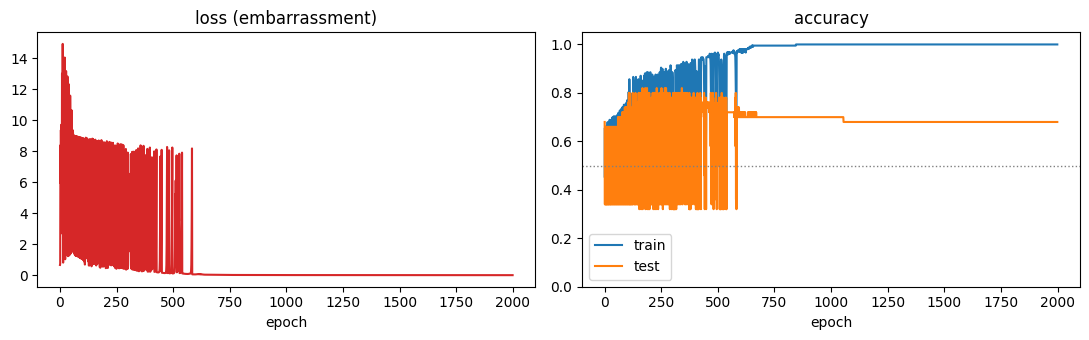


  one neuron (you, today):            68%
  the lecture's 17-neuron network:    64%
  a rock that always says 'cat':      66%


In [10]:
from tinynet import Net, load_cat_data

X_train, y_train, X_test, y_test, *_ = load_cat_data()

one_neuron = Net(layers=[12288, 1])          # no hidden layers: pure logistic regression
one_neuron.train(X_train, y_train, X_test, y_test, epochs=2000, lr=0.05, log_every=500)
one_neuron.plot()

print(f"\n  one neuron (you, today):            {one_neuron.accuracy(X_test, y_test):.0%}")
print(f"  the lecture's 17-neuron network:    64%")
print(f"  a rock that always says 'cat':      66%")

## Sit with that for a second

**One neuron just beat the 17-neuron "deep" network from the lecture.** More neurons, more layers, more parameters — *worse* result. If depth were free power, the challenge leaderboard would be a staircase; instead you've all discovered it's a lottery with a low ceiling.

So is depth a scam? No — the entire modern world runs on deep networks. Which leaves only one honest conclusion: **depth is real power that we don't yet know how to handle.** Making depth actually pay is, more or less, the plot of the next seven weeks.

### And one more thing…

Your hand-built training loop crawled through 200 animals one at a time, and you felt the runtime. `tinynet` just chewed through 209 images × 12,288 features × 2,000 epochs — **over five billion multiplications, in a few seconds** — and its training step contains **no loop over examples or features at all**.

Same math. Same answers. Hundreds of times faster. Next week we delete your loops.

---

### This ipynb is submitted by Shashank Goel